# 05. LLM 챗봇 만들기

---

## 이번 실습 목표

LangGraph와 `ChatOpenAI`를 결합해 **LLM 챗봇 그래프**를 만든다.

이번 실습에서 다루는 핵심은 다음과 같다.

| 구분 | 내용 |
|---|---|
| 기본 챗봇 | `MessagesState`를 사용해 사용자 메시지를 LLM에 전달한다. |
| 시스템 프롬프트 | `SystemMessage`로 챗봇의 역할과 응답 방식을 제어한다. |
| 멀티턴 대화 | 이전 메시지를 직접 누적해 문맥을 유지한다. |
| 스트리밍 | `stream_mode="messages"`로 LLM 토큰을 실시간 출력한다. |
| 조건부 분기 | 사용자 질문 수준에 따라 전문가 모드와 입문자 모드로 분기한다. |

---

## 핵심: `MessagesState`

`MessagesState`는 LangGraph에서 대화 메시지를 다룰 때 자주 사용하는 prebuilt State이다.

```python
from langgraph.graph import MessagesState
```

개념적으로는 다음과 같은 구조로 이해하면 된다.

```python
# 개념적 구조
class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
```

즉, `messages` 필드는 일반 리스트처럼 완전히 덮어써지는 것이 아니라,  
새 메시지가 들어오면 기존 메시지 뒤에 누적된다.

---


## 주의: 이 실습의 대화 기억 방식

이번 실습은 멀티턴 대화는 **checkpointer 기반 영속 메모리**가 아니다.
여기서는 다음 방식으로 문맥을 유지한다.

```text
이전 HumanMessage + 이전 AIMessage + 새 HumanMessage
    ↓
다시 app.invoke()에 전달
```

즉, 이전 대화 내용을 `messages` 리스트에 직접 누적해 다음 호출에 넣는 방식이다.  
실제 서비스에서는 `checkpointer` 또는 DB를 사용해 세션별 대화 상태를 저장할 수 있다.

## 환경 변수 로딩

In [1]:
from dotenv import load_dotenv
import os
load_dotenv(override=True, dotenv_path="../.env")
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(
        "OPENAI_API_KEY가 설정되어 있지 않습니다. .env 파일에 OPENAI_API_KEY를 추가하세요."
    )

## 그래프 그리기

In [2]:
from IPython.display import Image, display
def show_graph(app) -> None:
    """LangGraph 그래프를 이미지로 출력하고, 실패하면 ASCII 그래프로 대체한다."""
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

---

## 1. 가장 단순한 챗봇

노드 하나짜리 챗봇을 만든다.

실행 흐름은 다음과 같다.

```text
START → 챗봇 노드 → END
```

`챗봇 노드`는 현재 `messages`를 LLM에 전달하고, LLM 응답을 다시 `messages`에 추가한다.

LLM 준비 완료


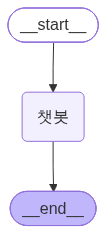

In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
print("LLM 준비 완료")

def chatbot_node(state: MessagesState) -> dict:
    """사용자 메시지를 LLM에 전달하고 AI 응답을 State에 추가한다."""

    # state["messages"]에는 HumanMessage, AIMessage 등 대화 메시지들이 들어 있다.
    # 가장 단순한 챗봇에서는 현재 messages 전체를 그대로 LLM에 전달한다.
    response = llm.invoke(state["messages"]) # llm invoke
    print('response :', response)

    # MessagesState의 messages 필드는 add_messages reducer가 적용되어 있다.
    # 따라서 {"messages": [response]}를 반환하면 기존 messages 뒤에 AI 응답이 추가된다.
    return {"messages": [response]}  

# 1) 챗봇 노드를 StateGraph에 추가한다.
builder = StateGraph(MessagesState)

# 2) 챗봇 역할을 수행할 노드를 등록한다.
builder.add_node("챗봇", chatbot_node)

# 3) START -> 챗봇 -> END 형태로 그래프를 구성한다.
builder.add_edge(START, "챗봇")
builder.add_edge("챗봇", END)

# 4) 그래프를 컴파일하여 실행 가능한 형태로 만든다.
app = builder.compile()

try:
    show_graph(app)
except:
    print(app.get_graph().draw_ascii())

### 단일 질문 테스트

In [ ]:
# 단일 질문 테스트
result = app.invoke({ # langgraph invoke
    "messages": [HumanMessage(content="파이썬이 뭔가요? 한 문장으로 설명해줘.")]
})

print("\n[응답]")
print(result["messages"][-1].content)

response : content='파이썬은 다양한 프로그래밍 작업에 사용되는 고급 프로그래밍 언어로, 문법이 간결하고 배우기 쉬워 많은 개발자들에게 인기가 있습니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 25, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b763061467', 'id': 'chatcmpl-EQoKD7uxn39HLytiRcu2h8gCyOaIR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a0c7cf-d98d-7e62-b16e-aa1edbd7b6bf-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 25, 'output_tokens': 40, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'

In [6]:
print(result['messages'])

[HumanMessage(content='파이썬이 뭔가요? 한 문장으로 설명해줘.', additional_kwargs={}, response_metadata={}, id='092aaea9-a765-44b7-beff-365cea7ef541'), AIMessage(content='파이썬은 다양한 프로그래밍 작업에 사용되는 고급 프로그래밍 언어로, 문법이 간결하고 배우기 쉬워 많은 개발자들에게 인기가 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 25, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b763061467', 'id': 'chatcmpl-EQoKD7uxn39HLytiRcu2h8gCyOaIR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0c7cf-d98d-7e62-b16e-aa1edbd7b6bf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={

In [7]:
question = {
    "messages": [HumanMessage(content="파이썬이 뭔가요? 한 문장으로 설명해줘.")]
}

for step in app.stream(question):
    print(step)

response : content='파이썬은 간결하고 읽기 쉬운 문법을 가진 고급 프로그래밍 언어로, 웹 개발, 데이터 분석, 인공지능 등 다양한 분야에서 널리 사용됩니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 25, 'total_tokens': 69, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b763061467', 'id': 'chatcmpl-EQoQvm8L0DOxPuNCRgqMIKR4gYW50', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a0c7d6-3812-73a2-b02f-168df5198028-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 25, 'output_tokens': 44, 'total_tokens': 69, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details':

---

## 2. 시스템 프롬프트 추가

`SystemMessage`는 LLM에게 역할, 응답 기준, 말투를 지정할 때 사용한다.

여기서는 챗봇을 **파이썬 튜터**로 설정한다.

중요한 점은 다음과 같다.

```text
SystemMessage + 기존 대화 messages
    ↓
LLM 호출
    ↓
AIMessage만 State에 추가
```

즉, 시스템 프롬프트는 LLM 호출 시 앞에 붙여 사용하되,  
반환 State에는 AI 응답만 추가한다.

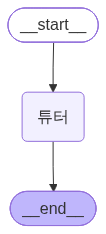

In [15]:
SYSTEM_PROMPT = """당신은 친절한 파이썬 튜터입니다.
- 초보자도 이해할 수 있게 쉽게 설명하세요
- 핵심만 간결하게 답변하세요
- 예시 코드는 짧게 보여주세요"""

def tutor_node(state: MessagesState) -> dict:
    # SystemMessage는 LLM 호출용 컨텍스트로만 사용한다.
    # state["messages"] 앞에 붙이면 LLM은 이 역할을 기준으로 답변한다.
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]

    response = llm.invoke(messages)

    # 시스템 프롬프트는 State에 누적하지 않고, AI 응답만 messages에 추가한다.
    return {"messages": [response]}

# 1) 챗봇 노드를 StateGraph에 추가한다
builder = StateGraph(MessagesState)

# 2) 챗봇 역할을 수행할 노드를 등록한다
builder.add_node("튜터", tutor_node)

# 3) START -> 챗봇 -> END 형태로 그래프를 구성한다
builder.add_edge(START, "튜터")
builder.add_edge("튜터", END)

# 4) 그래프를 컴파일하여 실행 가능한 형태로 만든다
app2 = builder.compile()

try:
    show_graph(app2)
except:
    print(app2.get_graph().draw_ascii())

In [9]:
# 질문 테스트
result = app2.invoke({
    "messages": [HumanMessage(content="리스트와 튜플의 차이가 뭔가요?")]
})
print(result["messages"][-1].content)

리스트와 튜플은 모두 여러 값을 저장할 수 있는 자료형이지만, 몇 가지 중요한 차이가 있습니다.

1. **변경 가능성**:
   - **리스트**: 변경 가능합니다. 즉, 리스트의 요소를 추가, 삭제, 수정할 수 있습니다.
   - **튜플**: 변경 불가능합니다. 한 번 생성하면 요소를 바꿀 수 없습니다.

2. **표기법**:
   - **리스트**: 대괄호 `[]`로 생성합니다.
   - **튜플**: 소괄호 `()`로 생성합니다.

3. **성능**:
   - 튜플은 리스트보다 메모리를 덜 사용하고, 성능이 더 빠릅니다.

### 예시 코드

```python
# 리스트
my_list = [1, 2, 3]
my_list[0] = 10  # 변경 가능
print(my_list)  # [10, 2, 3]

# 튜플
my_tuple = (1, 2, 3)
# my_tuple[0] = 10  # 오류 발생! 변경 불가능
print(my_tuple)  # (1, 2, 3)
```

리스트는 변경할 수 있을 때 사용하고, 튜플은 변경하지 않을 때 사용하세요.


In [16]:
print(result["messages"])

[HumanMessage(content='리스트와 튜플의 차이가 뭔가요?', additional_kwargs={}, response_metadata={}, id='7fc8e7f0-9738-4dfa-80cb-361dfe6dfc15'), AIMessage(content='리스트와 튜플은 모두 여러 값을 저장할 수 있는 자료형이지만, 몇 가지 중요한 차이가 있습니다.\n\n1. **변경 가능성**:\n   - **리스트**: 변경 가능합니다. 즉, 리스트의 요소를 추가, 삭제, 수정할 수 있습니다.\n   - **튜플**: 변경 불가능합니다. 한 번 생성하면 요소를 바꿀 수 없습니다.\n\n2. **표기법**:\n   - **리스트**: 대괄호 `[]`로 생성합니다.\n   - **튜플**: 소괄호 `()`로 생성합니다.\n\n3. **성능**:\n   - 튜플은 리스트보다 메모리를 덜 사용하고, 성능이 더 빠릅니다.\n\n### 예시 코드\n\n```python\n# 리스트\nmy_list = [1, 2, 3]\nmy_list[0] = 10  # 변경 가능\nprint(my_list)  # [10, 2, 3]\n\n# 튜플\nmy_tuple = (1, 2, 3)\n# my_tuple[0] = 10  # 오류 발생! 변경 불가능\nprint(my_tuple)  # (1, 2, 3)\n```\n\n리스트는 변경할 수 있을 때 사용하고, 튜플은 변경하지 않을 때 사용하세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 283, 'prompt_tokens': 74, 'total_tokens': 357, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, '

In [10]:
for step in app2.stream({"messages": [HumanMessage(content="리스트와 튜플의 차이가 뭔가요?")]}):
    print(step)

{'튜터': {'messages': [AIMessage(content='리스트와 튜플의 차이는 다음과 같습니다:\n\n1. **변경 가능성**:\n   - **리스트**: 변경 가능(mutable)합니다. 즉, 내용을 수정할 수 있습니다.\n   - **튜플**: 변경 불가능(immutable)합니다. 한 번 생성하면 수정할 수 없습니다.\n\n2. **표기법**:\n   - **리스트**: 대괄호 `[]`로 만듭니다.\n   - **튜플**: 소괄호 `()`로 만듭니다.\n\n3. **성능**:\n   - 튜플은 리스트보다 메모리를 적게 사용하고, 성능이 더 빠릅니다.\n\n### 예시 코드:\n\n```python\n# 리스트\nmy_list = [1, 2, 3]\nmy_list[0] = 10  # 수정 가능\nprint(my_list)   # [10, 2, 3]\n\n# 튜플\nmy_tuple = (1, 2, 3)\n# my_tuple[0] = 10  # 오류 발생: 튜플은 수정할 수 없음\nprint(my_tuple)   # (1, 2, 3)\n```\n\n리스트는 수정이 필요할 때, 튜플은 변경이 필요 없는 데이터를 사용할 때 적합합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 278, 'prompt_tokens': 74, 'total_tokens': 352, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tok

---

## 3. 멀티턴 대화 (대화 기록 유지)

이 예제에서는 이전 대화를 `messages` 리스트에 직접 누적해 문맥을 유지한다.

```text
1턴 입력: [HumanMessage("내 이름은 민준이에요.")]
1턴 결과: [HumanMessage(...), AIMessage(...)]

2턴 입력: [HumanMessage(...), AIMessage(...), HumanMessage("딕셔너리가 뭔가요?")]
2턴 결과: [HumanMessage(...), AIMessage(...), HumanMessage(...), AIMessage(...)]
```

이 방식은 수업용으로 이해하기 쉽다.  
다만 실제 서비스에서 여러 사용자와 여러 세션을 관리하려면 checkpointer 또는 DB 저장 구조가 필요하다.

In [13]:
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage

def chat_session(app, questions: list[str], system: str = "") -> list[BaseMessage]:
    """여러 질문을 순서대로 실행하면서 messages를 직접 누적한다."""
    messages: list[BaseMessage] = []

    print("=" * 55)
    for i, question in enumerate(questions, 1):
        # 1) 새 사용자 질문을 messages에 추가한다
        messages.append(HumanMessage(content=question))

        # 2) 지금까지의 전체 대화 기록을 그래프에 전달하여 응답을 받는다
        result = app.invoke({"messages": messages}) # graph invoke -> llm invoke

        # 3) LangGraph 노드에서 반환된 AI 응답을 messages에 추가한다
        messages = result["messages"]  # 전체 대화 기록을 업데이트
        print('m :', messages)
        # 4) 이번 턴의 AI 응답을 출력한다
        ai_response = result["messages"][-1]

        print(f"[{i}] 사용자: {question}")
        print(f"     AI    : {ai_response.content}")
        print("-" * 55)

    return messages

In [14]:
# 3턴 대화 - 이전 대화를 기억하는지 확인
conversion = chat_session(
    app2,
    questions=[
        "내 이름은 민준이에요.",
        "파이썬 딕셔너리가 뭔가요?",
        "제 이름이 뭐라고 했죠?",   # 문맥 기억 테스트
    ]
)

m : [HumanMessage(content='내 이름은 민준이에요.', additional_kwargs={}, response_metadata={}, id='46b99724-2d9d-4438-9847-fdd7ae42f46d'), AIMessage(content='안녕하세요, 민준님! 반갑습니다. 파이썬에 대해 궁금한 점이 있으면 언제든지 물어보세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 68, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5f98535a9a', 'id': 'chatcmpl-EQp6qwwpbNei6XAu76K5zWTyVcVZ1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0c7fd-defc-75c1-8e95-89e9e0c4e5fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_t

In [14]:
conversion

[HumanMessage(content='내 이름은 민준이에요.', additional_kwargs={}, response_metadata={}, id='a2d19cf9-ce81-4c5e-a2b9-1ec75c50078b'),
 AIMessage(content='안녕하세요, 민준님! 파이썬에 대해 궁금한 점이 있으신가요? 어떤 도움이 필요하신지 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 68, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_800187fee2', 'id': 'chatcmpl-DpGj7rJQVaZ3udb4ErkUcE7vh3T4X', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eb283-181c-7ec1-9c3e-77978cf8ab24-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 33, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [17]:
print(type(conversion))

<class 'list'>


---

## 4. 스트리밍 응답

`stream()`을 사용하면 그래프 실행 중 발생하는 출력을 단계적으로 받을 수 있다.

여기서는 `stream_mode="messages"`를 사용한다.
이 모드는 LLM이 생성하는 메시지 조각을 토큰 단위로 출력할 때 사용한다.

```python
for chunk, metadata in app.stream(..., stream_mode="messages"):
    ...
```

`metadata`에는 어떤 노드에서 생성된 토큰인지 등 실행 관련 정보가 함께 들어올 수 있다.

In [26]:
# stream_mode="messages"로 토큰 단위 스트리밍
print("[스트리밍 응답]")
print("-" * 40)
i = 0
for chunk, metadata in app2.stream(
    {
        "messages": [
            HumanMessage(content="파이썬 for 루프를 간단히 설명해줘")
        ]
    },
    stream_mode="messages",
):
    # stream_mode="messages"에서는 LLM 토근 조각과 메타데이터를 반환한다.
    # chunk.content에는 토큰 조각이 들어 있는지 판단함
    if hasattr(chunk, "content") and chunk.content:
        print(chunk.content, end="", flush=True)

    i += 1
    print('i :', i)

print("\n" + "-" * 40)

[스트리밍 응답]
----------------------------------------
i : 1
`i : 2
fori : 3
`i : 4
 루i : 5
프i : 6
는i : 7
 리스트i : 8
,i : 9
 튜i : 10
플i : 11
,i : 12
 문자열i : 13
 같은i : 14
 반복i : 15
 가능한i : 16
 객체i : 17
의i : 18
 각i : 19
 요소i : 20
를i : 21
 하나i : 22
씩i : 23
 가져i : 24
와i : 25
서i : 26
 반복i : 27
 작업i : 28
을i : 29
 수행i : 30
할i : 31
 때i : 32
 사용i : 33
합니다i : 34
.

i : 35
###i : 36
 기본i : 37
 구조i : 38

i : 39
```i : 40
pythoni : 41

i : 42
fori : 43
 요소i : 44
 ini : 45
 반복i : 46
가능i : 47
한i : 48
객i : 49
체i : 50
:
i : 51
   i : 52
 #i : 53
 실행i : 54
할i : 55
 코드i : 56

i : 57
``i : 58
`

i : 59
###i : 60
 예i : 61
시i : 62

i : 63
리i : 64
스트i : 65
의i : 66
 요소i : 67
를i : 68
 출력i : 69
하는i : 70
 예i : 71
시i : 72
입니다i : 73
.
i : 74
```i : 75
pythoni : 76

i : 77
fri : 78
uitsi : 79
 =i : 80
 ['i : 81
사i : 82
과i : 83
',i : 84
 'i : 85
바i : 86
나i : 87
나i : 88
',i : 89
 'i : 90
체i : 91
리i : 92
']
i : 93
fori : 94
 fruiti : 95
 ini : 96
 fruitsi : 97
:
i : 98
   i : 99
 printi : 100
(fi : 101
ruiti : 102
)
i : 10

---
## 5. 조건부 Edge를 활용한 챗봇 (간단한 분기)

사용자 입력에 따라 다음 두 가지 모드로 분기한다.

| 모드 | 조건 | 실행 노드 |
|---|---|---|
| 전문가 모드 | 질문에 `전문`, `심화`, `내부`, `CPython` 등이 포함됨 | `전문가봇` |
| 입문자 모드 | 그 외 일반 질문 | `입문자봇` |

이번 예제에서는 `MessagesState`를 확장해 `level` 필드를 추가한다.

```python
class RoutedChatState(MessagesState):
    level: NotRequired[str]
```

이렇게 하면 `messages`는 계속 누적하면서, 중간 판단 결과인 `level`도 State에 저장할 수 있다.


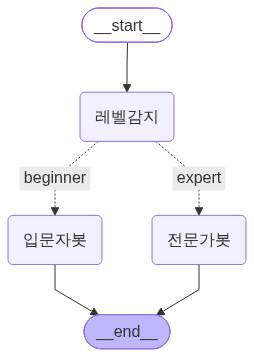

In [28]:
from typing import NotRequired, Literal

EXPERT_SYSTEM = "당신은 파이썬 전문가입니다. 기술적으로 정확하고 심층적으로 답변하세요."
BEGINNER_SYSTEM = "당신은 파이썬 입문자 튜터입니다. 비유와 쉬운 언어로 설명하세요."

# MessagesState를 상속 받아서 State의 재정의 함
class RoutedChatState(MessagesState):
    """messages에 분기 판단 결과(level)를 추가한 State이다."""

    # NotRequired를 사용하면 초기 입력에 level key가 없어도 된다.
    # level은 detect_level 노드가 실행된 뒤 State에 추가된다.
    level: NotRequired[str]

def detect_level(state: RoutedChatState) -> dict:
    """마지막 사용자 메시지를 보고 전문가/입문자 수준을 판단한다."""

    last_message = state["messages"][-1].content

    expert_keywords = ["전문", "심화", "내부", "CPython", "GIL", "메모리"]

    level = (
        "expert" if any(keyword in last_message for keyword in expert_keywords) else "beginner"
    )

    print(f"  [레벨감지] '{last_message[:25]}...' → {level}")

    # 중요:
    # MessagesState에서 messages를 그대로 반환하면 메시지가 중복 누적될 수 있다.
    # 따라서 여기서는 messages를 반환하지 않고, 새로 계산한 level만 반환한다.
    return {"level": level}


def expert_bot(state: RoutedChatState) -> dict:
    """전문가 수준의 시스템 프롬프트를 적용해 응답한다."""

    messages_for_llm = [SystemMessage(content=EXPERT_SYSTEM)] + state["messages"]
    response = llm.invoke(messages_for_llm)
    return {"messages": [response]}


def beginner_bot(state: RoutedChatState) -> dict:
    """입문자 수준의 시스템 프롬프트를 적용해 응답한다."""

    messages_for_llm = [SystemMessage(content=BEGINNER_SYSTEM)] + state["messages"]
    response = llm.invoke(messages_for_llm)
    return {"messages": [response]}


def route_level(state: RoutedChatState) -> Literal["expert", "beginner"]:
    """detect_level 노드가 저장한 level 값에 따라 다음 경로를 선택한다."""

    return state["level"]

builder = StateGraph(RoutedChatState)

builder.add_node("레벨감지", detect_level)
builder.add_node("전문가봇", expert_bot)
builder.add_node("입문자봇", beginner_bot)

builder.add_edge(START, "레벨감지")

# path_map을 명시하면 라우팅 함수의 반환값과 실제 노드명을 분리할 수 있다.
# 또한 그래프 시각화에서 가능한 분기 대상이 명확하게 표시된다.
builder.add_conditional_edges(
    "레벨감지",
    route_level,
    {
        "expert": "전문가봇",
        "beginner": "입문자봇",
    },
)

builder.add_edge("전문가봇", END)
builder.add_edge("입문자봇", END)

app3 = builder.compile()

show_graph(app3)

### 레벨별 응답 차이 비교

In [29]:
# 레벨별 응답 차이 비교
questions = [
    "파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘",  # → 전문가 모드
    "파이썬 함수가 뭔가요?",                            # → 입문자 모드
]

for q in questions:
    print(f"\n[질문] {q}")
    print("-" * 50)
    r = app3.invoke({"messages": [HumanMessage(content=q)]})
    print(r["messages"][-1].content[:500]) # 처음 500자만 출력


[질문] 파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘
--------------------------------------------------
  [레벨감지] '파이썬 GIL이 뭔가요? 전문가 수준으로 설명...' → expert
파이썬의 GIL(Global Interpreter Lock)은 CPython 인터프리터에서 사용되는 메커니즘으로, 한 번에 하나의 스레드만 Python 바이트코드를 실행할 수 있도록 보장합니다. GIL은 Python의 메모리 관리 및 객체 모델의 단순성을 유지하기 위해 도입되었으며, 다중 스레드 환경에서의 메모리 안전성을 보장하는 역할을 합니다.

### GIL의 동작 원리

1. **스레드 안전성**: Python 객체는 참조 카운팅 방식으로 메모리를 관리하는데, 여러 스레드가 동시에 객체를 수정하면 참조 카운트가 일관되지 않게 될 수 있습니다. GIL은 이러한 상황을 방지하기 위해, 스레드가 실행되는 동안 다른 스레드가 Python 바이트코드를 실행하지 못하도록 합니다.

2. **스레드 스위칭**: GIL은 기본적으로 스레드가 CPU를 점유하는 시간을 제한하여 정기적으로 스레드 간에 컨텍스트 스위칭을 수행합니다. Python에서는 이를 통해 스레드가 실행되는 시간 동안 GIL을

[질문] 파이썬 함수가 뭔가요?
--------------------------------------------------
  [레벨감지] '파이썬 함수가 뭔가요?...' → beginner
파이썬에서 함수는 마치 요리법과 같아요. 요리법은 특정한 재료를 가지고 음식을 만드는 방법을 알려주죠. 이와 비슷하게, 함수는 특정한 작업을 수행하기 위한 코드 블록입니다. 

예를 들어, 우리가 "사과를 잘라서 과일 샐러드를 만든다"는 요리법이 있다면, 이 요리법에서 "사과를 자르는" 부분이 바로 함수에 해당합니다. 한 번 함수를 만들어 놓으면, 필요할 때마다 그 함수를 호출(부르는 것)하여 같은 작업을 반복할 수 있어요.

함수를 만들 때는 `def`라

In [30]:
q = "파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘"
for step in app3.stream({"messages": [HumanMessage(content=q)]}):
    print("-"*10)
    print(step)

  [레벨감지] '파이썬 GIL이 뭔가요? 전문가 수준으로 설명...' → expert
----------
{'레벨감지': {'level': 'expert'}}
----------
{'전문가봇': {'messages': [AIMessage(content='파이썬의 GIL(Global Interpreter Lock)은 Python 인터프리터가 여러 스레드에서 동시에 실행되는 것을 제어하는 메커니즘입니다. GIL은 CPython 구현에서만 존재하는 개념으로, 다른 구현체들(예: Jython, IronPython 등)에서는 다르게 처리할 수 있습니다. GIL은 주로 다음과 같은 목적을 가지고 있습니다.\n\n### 1. 메모리 관리\n파이썬은 자동 메모리 관리를 위해 참조 카운팅을 사용합니다. 여러 스레드가 동시에 객체에 접근하면 참조 카운트가 불안정해질 수 있습니다. GIL은 이러한 동시 접근을 방지하여 메모리 관리의 일관성을 유지하도록 돕습니다.\n\n### 2. 스레드 안전성\nGIL은 CPython 인터프리터의 상태를 보호하여 동시에 여러 스레드가 내부 데이터 구조에 접근하는 것을 방지합니다. 이는 데이터 경쟁 조건을 피할 수 있게 하여 스레드 안전성을 제공합니다.\n\n### 3. 성능\nGIL은 단일 스레드에서 실행되는 경우에는 성능에 큰 영향을 미치지 않지만, 멀티스레딩 환경에서는 성능 저하를 초래할 수 있습니다. 특히 CPU 집약적인 작업에서는 GIL이 병렬 처리를 방해하여 여러 스레드를 동시에 활용할 수 없게 만듭니다.\n\n### GIL의 작동 방식\n- CPython 인터프리터는 GIL을 사용하여 한 번에 하나의 스레드만 실행할 수 있게 합니다. 즉, 스레드가 CPU를 사용할 때 GIL을 획득하고, 다른 스레드는 대기 상태가 됩니다.\n- GIL은 일정한 시간 간격으로 스레드를 전환하며, 이 과정은 "타임 슬라이스"라고 불립니다. 따라서, 스레드는 일정 시간 후 GIL을 놓아주고 다른 스레드가 실행될 수 있도록 합니다.\n- 이로 인해 I/O 바

---

## 정리

```python
# LangGraph 챗봇 기본 패턴

from langgraph.graph import MessagesState

def chatbot_node(state: MessagesState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}  # 기존 messages 뒤에 AIMessage가 누적됨

builder = StateGraph(MessagesState)
builder.add_node("챗봇", chatbot_node)
builder.add_edge(START, "챗봇")
builder.add_edge("챗봇", END)

app = builder.compile()

result = app.invoke({
    "messages": [HumanMessage(content="질문")]
})
```

| 방식 | 설명 |
|---|---|
| `MessagesState` | `messages` 필드를 누적 관리하는 대화용 State |
| `SystemMessage` | LLM의 역할, 응답 방식, 말투를 지정 |
| `invoke()` | 그래프를 한 번 실행하고 최종 State를 반환 |
| `stream(stream_mode="messages")` | LLM 메시지 조각을 토큰 단위로 스트리밍 |
| `add_conditional_edges()` | State에 따라 다음 노드를 선택 |
| `path_map` | 라우팅 함수 반환값과 실제 노드명을 명시적으로 연결 |

## 이 실습에서 특히 주의할 점

1. `MessagesState`에서 이미 존재하는 `messages`를 그대로 반환하면 메시지가 중복 누적될 수 있다.
2. 멀티턴 문맥 유지는 이 실습에서는 `messages` 리스트를 직접 누적하는 방식이다.
3. 실제 서비스에서는 checkpointer 또는 DB를 사용해 세션별 대화 이력을 저장하는 것이 적절하다.
4. 조건부 Edge는 `path_map`을 명시하면 실행 흐름과 그래프 시각화가 더 명확하다.

